# Лабораторная работа № 9. Распознавание изображений с помощью нейронных сетей
## Задание № 3. Реализация линейного нейрона

**Линейный нейрон** — это вычислительная единица, которая вычисляет **взвешенную сумму входов** и **возвращает её как есть**, без применения нелинейной функции:

$$y = \sum_{i=1}^{n} w_i x_i + b$$

Это **формула линейной регрессии**!

Отличие от перцептрона:  
 - Перцептрон: $ y = \text{step}(w^T x + b) $ → **классификация**  
 - Линейный нейрон:  $y = w^T x + b$ → **регрессия**

### 1. Создать синтетические данные

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Генерация данных
np.random.seed(42)
X = np.random.rand(100, 2) * 100  # площадь: 0–100 м², расстояние: 0–100 км
# Истинная зависимость: цена = 3000 * площадь - 500 * расстояние + шум
y = 3000 * X[:, 0] - 500 * X[:, 1] + np.random.randn(100) * 10000

print("Первые 5 примеров:")
for i in range(5):
    print(f"Площадь: {X[i,0]:.1f} м², Расст.: {X[i,1]:.1f} км → Цена: {y[i]:.0f} руб")

Первые 5 примеров:
Площадь: 37.5 м², Расст.: 95.1 км → Цена: 58026 руб
Площадь: 73.2 м², Расст.: 59.9 км → Цена: 191988 руб
Площадь: 15.6 м², Расст.: 15.6 км → Цена: 41937 руб
Площадь: 5.8 м², Расст.: 86.6 км → Цена: -33027 руб
Площадь: 60.1 м², Расст.: 70.8 км → Цена: 163589 руб


### 2. Реализовать линейный нейрон

In [2]:
class LinearNeuron:
    def __init__(self, learning_rate=0.0001, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01  # малая инициализация
        self.bias = 0.0

        for epoch in range(self.n_epochs):
            # Прямой проход
            y_pred = np.dot(X, self.weights) + self.bias

            # Ошибка (MSE)
            error = y_pred - y
            loss = np.mean(error ** 2)
            self.losses.append(loss)

            # Градиенты
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # Обновление весов (градиентный спуск)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### 3. Обучить и сравнить с линейной регрессией из `sklearn`

In [3]:
# Обучим линейный нейрон
neuron = LinearNeuron(learning_rate=0.0001, n_epochs=5000)
neuron.fit(X, y)

# Обучим LinearRegression из sklearn
lr = LinearRegression()
lr.fit(X, y)

# Предсказания
y_pred_neuron = neuron.predict(X)
y_pred_sklearn = lr.predict(X)

# Оценка качества
from sklearn.metrics import mean_squared_error

mse_neuron = mean_squared_error(y, y_pred_neuron)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print(f"\nMSE (линейный нейрон): {mse_neuron:.0f}")
print(f"MSE (sklearn LinearRegression): {mse_sklearn:.0f}")
print(f"\nВеса линейного нейрона: {neuron.weights}")
print(f"Sklearn веса: {lr.coef_}")
print(f"Смещение (bias): {neuron.bias:.1f} vs {lr.intercept_:.1f}")


MSE (линейный нейрон): 98725290
MSE (sklearn LinearRegression): 98138299

Веса линейного нейрона: [3017.75121965 -483.08708527]
Sklearn веса: [3033.86667742 -464.50539679]
Смещение (bias): -300.3 vs -2277.3


### 4. Визуализировать сходимость

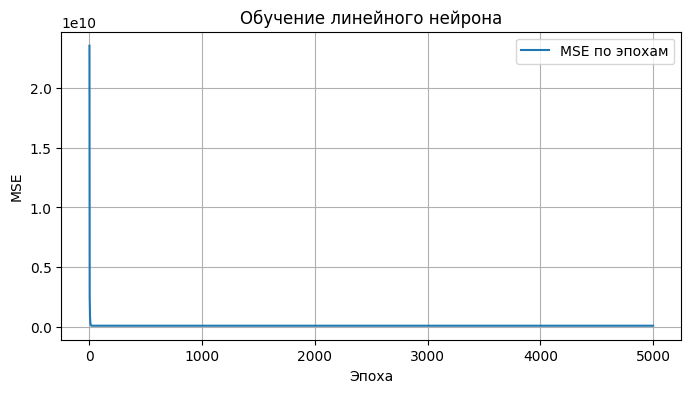

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(neuron.losses, label="MSE по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение линейного нейрона")
plt.grid(True)
plt.legend()
plt.show()

Дополнить предложенную реализацию линейного нейрона согласно плану:

1. Разделить выборку на тестовую (20%) и обучающую (80%), из состава которой выделить валидационную выборку (10% от исходного набора данных).
2. Проверить предсказания линейного нейрона и линейной регрессии на тестовой выборке.
3. Оценить качество (MSE, R²) линейного нейрона и линейной регрессии на тестовой выборке.
4. Визуализировать предсказания vs истинные значения на тетсовой выборке для линейного нейрона и линейной регрессии.
5. Построить валидационную кривую (MSE на обучающей и валидационной выборках по эпохам) для линейного нейрона.
6. Протестировать работу линейного нейрона и линейной регресии на примере предсказания цены для конкретного дома с расчётом ошибки, например дом с характеристиками площадь = 85 м², расстояние до центра = 5 км.
7. Оценить реалистичность предсказаний.
8. Используя `ipywidgets` создать интерактивный виджет для предсказания цены дома как на рисунке:
![ipywidgets-example.png](https://github.com/maryiad/ml-example/blob/main/img/ipywidgets-example.png?raw=true)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [7]:
LN = LinearNeuron()
LR = LinearRegression()

In [8]:
LN.fit(X_train, y_train)
LR.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
LN_pred = LN.predict(X_test)
LR_pred = LR.predict(X_test)

In [10]:
print("MSE Linear Neuron: ", mean_squared_error(y_test, LN_pred))
print("MSE Linear Regression: ", mean_squared_error(y_test, LR_pred))

MSE Linear Neuron:  70809323.46919957
MSE Linear Regression:  72819841.32740939


In [11]:
from sklearn.metrics import r2_score

print("R^2 Linear Neuron: ", r2_score(y_test, LN_pred))
print("R^2 Linear Regression: ", r2_score(y_test, LR_pred))

R^2 Linear Neuron:  0.9902540538563943
R^2 Linear Regression:  0.9899773332522864


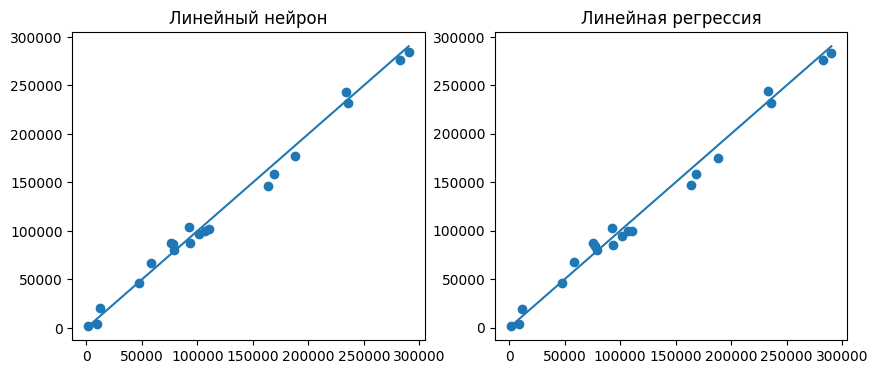

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(y_test, LN_pred)
axs[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
axs[0].set_title('Линейный нейрон')
axs[1].scatter(y_test, LR_pred)
axs[1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
axs[1].set_title('Линейная регрессия')
plt.show()

In [13]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

class LinearNeuronVC(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.0001, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

        for epoch in range(self.n_epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y
            loss = np.mean(error ** 2)
            self.losses.append(loss)

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self  # важно для scikit-learn

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    def get_params(self, deep=True):
        # Возвращает параметры конструктора
        return {"learning_rate": self.lr, "n_epochs": self.n_epochs}
    
    def set_params(self, **parameters):
        # Устанавливает параметры (нужно для ValidationCurveDisplay)
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

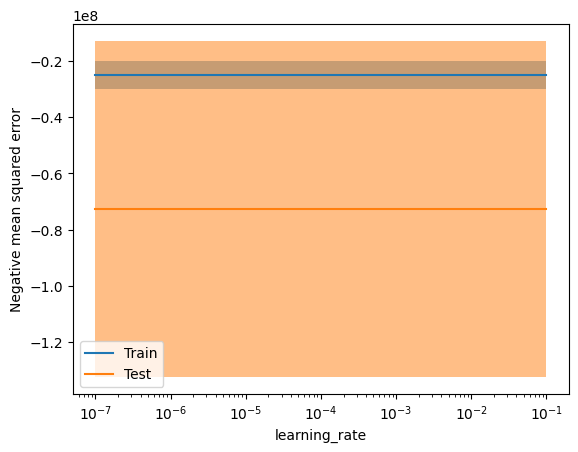

In [14]:
from sklearn.model_selection import ValidationCurveDisplay

ValidationCurveDisplay.from_estimator(
    LinearNeuronVC(), 
    X_val, 
    y_val, 
    param_name="learning_rate",
    param_range=np.logspace(-7, -1, 10),
    scoring="neg_mean_squared_error"
)

In [15]:
LN.predict([[85, 5]]), LR.predict([[85, 5]])

(array([252381.65200041]), array([251498.29188402]))

In [16]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

def create_house_price_widget(model_linear, model_sklearn):
    # Ползунки
    area_slider = widgets.FloatSlider(
        value=66.0,
        min=20,
        max=200,
        step=0.5,
        description='Площадь (м²):',
        style={'description_width': 'initial'}
    )
    
    distance_slider = widgets.FloatSlider(
        value=18.5,
        min=1,
        max=50,
        step=0.1,
        description='Расстояние (км):',
        style={'description_width': 'initial'}
    )

    output = widgets.HTML()
    
    def update_prediction(change):
        X_input = np.array([[area_slider.value, distance_slider.value]])

        pred_linear = model_linear.predict(X_input)[0]
        pred_sklearn = model_sklearn.predict(X_input)[0]

        html = f"""
        <div style="font-family: Arial, sans-serif; padding: 10px;">
            <h3>Предсказание цены дома</h3>
            <p><b>Площадь:</b> {area_slider.value} м²<br>
            <b>Расстояние до центра:</b> {distance_slider.value} км</p>
            <p><b>Линейный нейрон:</b> {pred_linear:,.0f} руб<br>
            <b>Sklearn LinearRegression:</b> {pred_sklearn:,.0f} руб</p>
        </div>
        """
        output.value = html

    area_slider.observe(update_prediction, 'value')
    distance_slider.observe(update_prediction, 'value')

    update_prediction(None)

    display(widgets.VBox([
        area_slider,
        distance_slider,
        output
    ]))

model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

model_linear = LinearNeuron()
model_linear.fit(X_train, y_train)

create_house_price_widget(model_linear, model_sklearn)